In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [39]:
df_raw = pd.read_csv("Ecommerce Churn Dataset 2025.csv")
df_raw.head()

,order_id,customer_id,age,product_id,country,signup_date,last_purchase_date,cancellations_count,subscription_status,order_date,unit_price,quantity,purchase_frequency,preferred_category,product_name,category,gender
0,ORD5000,CUST1000,39,PROD200,Canada,01-07-2021,2/21/2023,0,active,8/20/2024,78.21,5,37,Sports,Football,Sports,Female
1,ORD5001,CUST1001,61,PROD201,USA,10/19/2020,12-08-2021,0,active,7/17/2025,64.02,8,35,Sports,Refrigerator,Home,Female
2,ORD5002,CUST1002,26,PROD202,Pakistan,06-10-2023,09-04-2023,3,cancelled,03-12-2025,604.14,2,44,Electronics,Hoodie,Clothing,Female
3,ORD5003,CUST1003,54,PROD203,India,7/30/2023,2/20/2024,4,paused,9/19/2024,84.66,4,1,Sports,Conditioner,Beauty,Male
4,ORD5004,CUST1004,50,PROD204,India,12-09-2020,9/14/2024,0,active,08-08-2024,62.66,7,35,Sports,Smartwatch,Electronics,Male


In [40]:
def parse_mixed_dates(series):
    """Helper function to handle inconsistent date formats."""
    result = pd.Series(index=series.index, dtype='datetime64[ns]')
    mask_slash = series.str.contains('/', na=False)
    result[mask_slash] = pd.to_datetime(series[mask_slash], format='%m/%d/%Y', errors='coerce')
    mask_dash  = series.str.contains('-', na=False)
    result[mask_dash]  = pd.to_datetime(series[mask_dash], format='%d-%m-%Y', errors='coerce')
    return result

def preprocess_data(df):
    """One-stop function for cleaning, standardization, and advanced feature engineering."""
    df_proc = df.copy()

    # 1. Date Parsing & Anomaly Treatment
    date_cols = ['signup_date', 'last_purchase_date', 'order_date']
    for col in date_cols:
        df_proc[col] = parse_mixed_dates(df_proc[col])

    # Catch Obvious "Time-Travel" Typos (Pinned for reproducibility)
    DATE_OF_ANALYSIS = pd.to_datetime("2026-03-29")
    future_mask = (df_proc['signup_date'] > DATE_OF_ANALYSIS) | \
                  (df_proc['last_purchase_date'] > DATE_OF_ANALYSIS) | \
                  (df_proc['order_date'] > DATE_OF_ANALYSIS)

    # Combined logic check (Negative Tenure or Ghost Orders)
    logical_mask = (df_proc['signup_date'] > df_proc['last_purchase_date']) | \
                   (df_proc['signup_date'] > df_proc['order_date'])

    df_proc = df_proc[~(future_mask | logical_mask)].copy()

    # 2. Categorical Standardization
    cat_cols = ['country', 'subscription_status', 'preferred_category', 'category', 'gender']
    for col in cat_cols:
        if col in df_proc.columns:
            df_proc[col] = df_proc[col].astype(str).str.strip().str.lower()

    # 3. Winsorization (99th Percentile Capping)
    num_cols = ['unit_price', 'quantity', 'purchase_frequency']
    for col in num_cols:
        df_proc[col] = df_proc[col].clip(upper=df_proc[col].quantile(0.99))


    # 5. Feature Engineering: Basic RFM
    # Dynamically anchor to the latest valid transaction
    REFERENCE_DATE = df_proc['last_purchase_date'].max() + pd.Timedelta(days=1)

    df_proc['recency_days'] = (REFERENCE_DATE - df_proc['last_purchase_date']).dt.days
    df_proc['tenure_days'] = (REFERENCE_DATE - df_proc['signup_date']).dt.days
    df_proc['clv_proxy'] = df_proc['unit_price'] * df_proc['quantity'] * df_proc['purchase_frequency']

    # 6. Feature Engineering: Advanced Ratios
    df_proc['recency_tenure_ratio'] = df_proc['recency_days'] / (df_proc['tenure_days'] + 1)
    df_proc['value_velocity'] = df_proc['clv_proxy'] / (df_proc['tenure_days'] + 1)
    df_proc['purchase_intensity'] = df_proc['quantity'] / (df_proc['purchase_frequency'] + 1)

    # 7. Feature Engineering: Risk Flags
    df_proc['is_high_risk_country'] = (df_proc['country'] == 'india').astype(int)
    df_proc['is_high_risk_category'] = df_proc['category'].isin(['beauty', 'home']).astype(int)
    df_proc['is_senior_risk'] = (df_proc['age'] >= 60).astype(int)

    q90_whale = df_proc['clv_proxy'].quantile(0.90)
    df_proc['is_whale_risk'] = (df_proc['clv_proxy'] >= q90_whale).astype(int)

    # 8. Final Column Cleanup
    cols_to_drop = ['signup_date', 'last_purchase_date', 'order_date']
    df_proc = df_proc.drop(columns=cols_to_drop)

    return df_proc

# Apply the master function to the original raw data
df_final = preprocess_data(df_raw)

# Final Verification Output
print(f"Final Dynamic Dataset Shape: {df_final.shape}")
print(f"Total Columns: {len(df_final.columns)}")
print("\n--- Final Feature List ---")
print(df_final.columns.tolist())

Final Dynamic Dataset Shape: (1879, 24)
Total Columns: 24

--- Final Feature List ---
['order_id', 'customer_id', 'age', 'product_id', 'country', 'cancellations_count', 'subscription_status', 'unit_price', 'quantity', 'purchase_frequency', 'preferred_category', 'product_name', 'category', 'gender', 'recency_days', 'tenure_days', 'clv_proxy', 'recency_tenure_ratio', 'value_velocity', 'purchase_intensity', 'is_high_risk_country', 'is_high_risk_category', 'is_senior_risk', 'is_whale_risk']


In [41]:
# customer segmentation using kmeans clustering with rfm framework
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
rfm_features = df_final[['recency_days', 'tenure_days', 'clv_proxy']]
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)
kmeans = KMeans(n_clusters=4, random_state=42)
df_final['customer_segment'] = kmeans.fit_predict(rfm_scaled)

# # View the centroids to help label the cohorts based on business logic
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroid_df = pd.DataFrame(centroids, columns=['recency_days', 'tenure_days', 'clv_proxy'])
print("\n--- Cluster Centroids (Unscaled) ---")
print(centroid_df)    




--- Cluster Centroids (Unscaled) ---
   recency_days  tenure_days     clv_proxy
0    526.742525  1090.722591  15163.490355
1    482.779097  1676.947743  17817.626010
2   1260.505219  1653.421712  21029.375298
3    616.588859  1300.745358  58108.143729


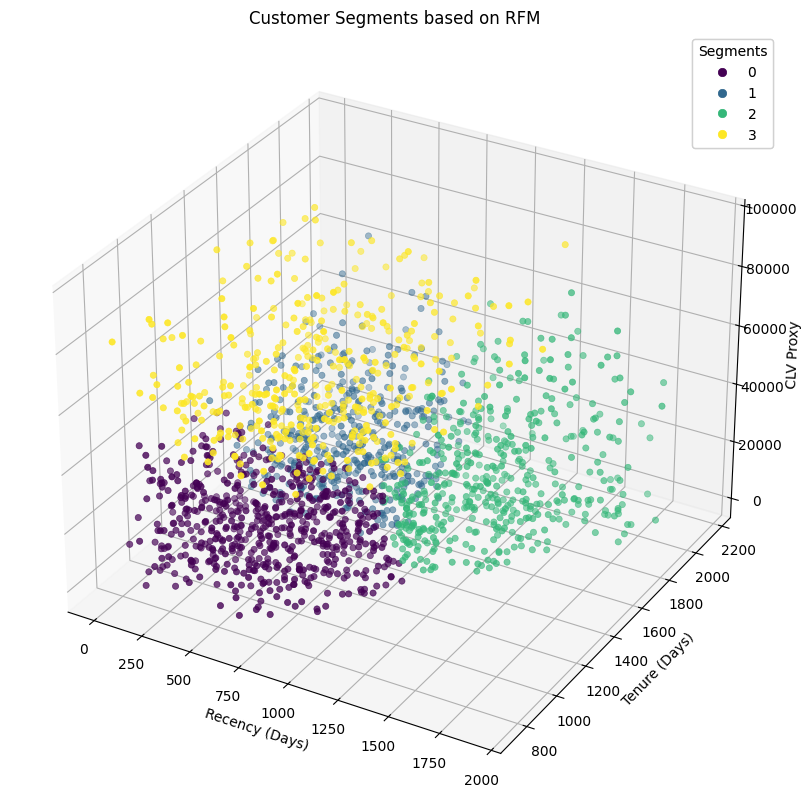

In [42]:
# 3D Scatter of RFM Clusters
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df_final['recency_days'], df_final['tenure_days'], df_final['clv_proxy'], 
                     c=df_final['customer_segment'], cmap='viridis', linewidth=0.5, marker='o')
ax.set_title('Customer Segments based on RFM')
ax.set_xlabel('Recency (Days)')
ax.set_ylabel('Tenure (Days)')
ax.set_zlabel('CLV Proxy')
legend1 = ax.legend(*scatter.legend_elements(), title="Segments")
ax.add_artist(legend1)
plt.show()

In [43]:
# cancelled and active rate by segment
segment_summary = df_final.groupby('customer_segment')['subscription_status'].value_counts(normalize=True).unstack().fillna(0)
print("\n--- Subscription Status Distribution by Customer Segment ---")
print(segment_summary)



--- Subscription Status Distribution by Customer Segment ---
subscription_status    active  cancelled    paused
customer_segment                                  
0                    0.606312   0.240864  0.152824
1                    0.610451   0.230404  0.159145
2                    0.599165   0.248434  0.152401
3                    0.591512   0.251989  0.156499


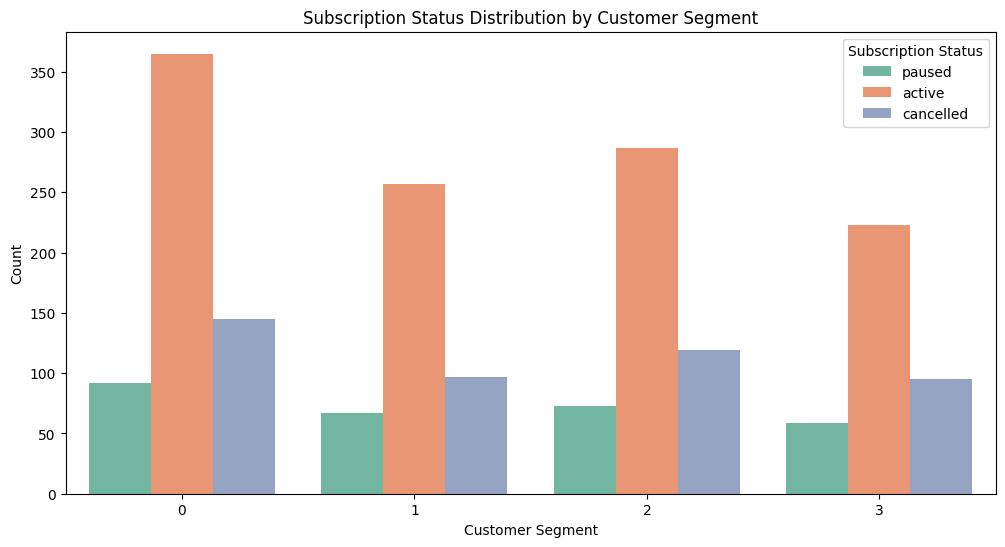

In [44]:
# plot subcription status distribution by segment
plt.figure(figsize=(12, 6))
sns.countplot(data=df_final, x='customer_segment', hue='subscription_status', palette='Set2')
plt.title('Subscription Status Distribution by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Count')
plt.legend(title='Subscription Status')
plt.show()